In [84]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

folder_path = 'mouseDataMainStudy'

exclude_ids = ['4089_trackingData', '4911_trackingData', '5788_trackingData', '1324_trackingData', '2477_trackingData']


csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
filtered_files = [
    file for file in csv_files
    if not any(ex_id in os.path.basename(file) for ex_id in exclude_ids)
]

dataframes = [pd.read_csv(file) for file in filtered_files]
# dataframes = [pd.read_csv(file) for file in csv_files]
print(len(dataframes))


38


### Entfernen ausgeschlossener Trials

Aus der Datei `trial_exclusion_overview.csv` werden alle ausgeschlossenen Trials (`trial_excl == 1`) identifiziert.  
Diese werden aus den DataFrames in `dataframes` anhand von `id`, `round` und `trial` entfernt; DataFrames ohne diese Spalten bleiben unverändert.


In [85]:
exclusion_df = pd.read_csv('trial_exclusion_overview.csv') 
excluded = exclusion_df[exclusion_df['trial_excl'] == 1][['id', 'round', 'trial']]
dataframes_without_excluded = []

for df in dataframes:
    if all(col in df.columns for col in ['id', 'round', 'trial']):
        merged = df.merge(excluded, on=['id', 'round', 'trial'], how='left', indicator=True)
        df_cleaned = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
        dataframes_without_excluded.append(df_cleaned)
    else:
        dataframes_without_excluded.append(df) 

### Aufteilen nach Block-Paaren

Jedes DataFrame aus `dataframes_without_excluded` wird von Zeilen der Phase `waitingForTarget` bereinigt (zur sicherheit, sollte nach dem Anpassen der Datenaufzeichnungslogik nicht mehr vorkommen, da die Daten erst ab dem Punkt aufgenommen werden, sobald das Ziel erscheint).  
Anschließend werden die Daten in vordefinierte Block-Paare (`1_2`, `3_4`, `5_6`, `7_8`) aufgeteilt und in `all_blocks` gesammelt.


In [86]:
block_pairs = [(1, 2), (3, 4), (5, 6), (7, 8)]
all_blocks = {f"{a}_{b}": [] for a, b in block_pairs}

for df in dataframes_without_excluded:
    df = df[df['phase'] != 'waitingForTarget']
    for a, b in block_pairs:
        df_block = df[df['round'].isin([a, b])].reset_index(drop=True)
        all_blocks[f"{a}_{b}"].append(df_block)

### Gruppieren nach Round und Trial

Für jedes Block-Paar werden die DataFrames in `all_blocks` nach `round` und `trial` gruppiert.  
Dabei werden `timestamp`, `pointerX` und `pointerY` als Listen aggregiert, während Meta-Informationen (`version`, `id`, `side`, `delay`) aus der ersten Zeile übernommen werden.  
Die gruppierten DataFrames werden in `grouped_blocks` gespeichert.


In [87]:
grouped_blocks = {
    '1_2': [],
    '3_4': [],
    '5_6': [],
    '7_8': []
}

for key in grouped_blocks.keys():
    for df in all_blocks[key]:
        df_grouped = df.groupby(['round', 'trial']).agg({
            'timestamp': list,
            'pointerX': list,
            'pointerY': list,
            'version': 'first',
            'id': 'first',
            'side': 'first',
            'delay': 'first'
        }).reset_index()
        grouped_blocks[key].append(df_grouped)


### Filter auf Basis der Startposition von PointerX

Für jeden gruppierten Trial in `grouped_blocks` wird geprüft, ob der erste Wert von `pointerX` im Bereich [-2.3, 2.3] liegt.  
Nur Trials, die diese Bedingung erfüllen, werden behalten.  

Die Gesamtzahl der Trials vor und nach dem Filtern wird gezählt, ebenso wie die Anzahl der entfernten Trials.

**Das Ganze ist einfach nur ein Sicherheitscheck, ob die Änderung am Spieldesign (dass man am Anfang in der Mitte bleiben muss) zum gewünschten Ergebnis geführt hat.
Bei den Daten der "Vorstudie" wurden hier bereits ~3700 Trials entfernt.**

In [88]:
before_total = 0
after_total = 0

for key, dfs in grouped_blocks.items():
    print(len(dfs))
    for i, df in enumerate(dfs):
        before_total += len(df)
        dfs[i] = df[df['pointerX'].apply(lambda x: -2.3 <= x[0] <= 2.3)].reset_index(drop=True)
        after_total += len(dfs[i])

print("Vorher:", before_total)
print("Nachher:", after_total)
print("Entfernt:", before_total - after_total)


38
38
38
38
Vorher: 16415
Nachher: 16415
Entfernt: 0


### Berechnung der euklidischen Schrittweiten

Für jeden Trial werden aus den `pointerX`- und `pointerY`-Werten die **Abstände zwischen aufeinanderfolgenden Punkten** berechnet:  

- `dx` und `dy` sind die Differenzen der X- und Y-Koordinaten zwischen zwei aufeinanderfolgenden Messungen.  
- `dist = sqrt(dx² + dy²)` ergibt die euklidische Distanz (https://journals.sagepub.com/doi/10.1177/1368430214538325) pro Schritt.  
- Die erste Distanz wird auf 0 gesetzt, da es keinen vorherigen Punkt gibt.


In [89]:
import numpy as np


def calculate_euclidean_distances(row):
    x = row['pointerX']
    y = row['pointerY']
    dx = np.diff(x)
    dy = np.diff(y)
    dist = np.sqrt(dx**2 + dy**2)
    return np.insert(dist, 0, 0.0)  # Schrittweiten, erste ist 0


### Proportionale Distanz zum Endpunkt https://journals.sagepub.com/doi/10.1177/1368430214538325

Für jeden Trial wird die euklidische Distanz jedes Cursorpunkts zum **letzten Punkt** (Endpunkt) berechnet.  
Anschließend wird diese Distanz normiert:  

- Der maximale Abstand im Trial wird als Referenz genommen.  
- Werte werden in den Bereich `[0, 1]` skaliert, wobei `1` dem Endpunkt entspricht und `0` dem weitesten Punkt entfernt.  

Falls der Trial keine Bewegung enthält, wird eine Liste aus Nullen zurückgegeben.


In [90]:
def calculate_proportional_distance_to_endpoint(row):
    x = np.array(row['pointerX'])
    y = np.array(row['pointerY'])
    
    target_x = x[-1]
    target_y = y[-1]
    
    dx = x - target_x
    dy = y - target_y
    
    dist_to_end = np.sqrt(dx**2 + dy**2)
    
    max_dist = np.max(dist_to_end)
    if max_dist == 0:
        return [0.0] * len(dist_to_end)  # Falls keine Bewegung
    else:
        proportional = 1 - (dist_to_end / max_dist)
        return proportional.tolist()


### Fortschritt zum Ziel berechnen

Aus den normierten Abständen zum Endpunkt (`euk_dist_to_end`, 0 = weit entfernt, 1 = am Ziel) wird der **Fortschritt zwischen aufeinanderfolgenden Zeitpunkten** berechnet:  

- `np.diff(proportional)` gibt die Veränderung pro Schritt.  
- Positive Werte = Bewegung **in Richtung Ziel**  
- Die erste Differenz wird auf 0 gesetzt, da es keinen vorherigen Punkt gibt.


In [91]:
def calculate_progress_to_target(row):
    proportional = np.array(row['euk_dist_to_end'])
    deltas = np.diff(proportional)
    deltas = np.insert(deltas, 0, 0.0)
    return deltas.tolist()


### Berechnung von Distanzmetriken pro Trial

Für jeden Trial in `grouped_blocks` werden drei Metriken berechnet:  

1. `euk_dist` → Schrittweite zwischen aufeinanderfolgenden Cursorpunkten  
2. `euk_dist_to_end` → normierte Entfernung zum Endpunkt (0 = weit weg, 1 = Ziel)  
3. `progress_to_target` → Fortschritt in Richtung Ziel zwischen aufeinanderfolgenden Punkten  

Fehler bei einzelnen Trials werden abgefangen und mit Angabe von Block und Index ausgegeben.  
Die berechneten Spalten werden in den jeweiligen DataFrames gespeichert.


In [92]:
for key, df_list in grouped_blocks.items():
    for i, df in enumerate(df_list):
        df = df.copy()
        try:
            df['euk_dist'] = df.apply(calculate_euclidean_distances, axis=1)
            df['euk_dist_to_end'] = df.apply(calculate_proportional_distance_to_endpoint, axis=1)
            df['progress_to_target'] = df.apply(calculate_progress_to_target, axis=1)
        except Exception as e:
            print(f"Fehler bei {key}[{i}]: {e}")
            continue

        df_list[i] = df


### Berechnung der Mausgeschwindigkeit pro Schritt

Für jeden Trial wird die Geschwindigkeit des Cursors zwischen aufeinanderfolgenden Messpunkten berechnet:  

1. `timestamps` → Zeitpunkte der Messungen  
2. `euk_dist` → Schrittweiten zwischen den Punkten  
3. Zeitdifferenzen zwischen den Messpunkten werden in Sekunden berechnet  
4. Geschwindigkeit pro Schritt = Distanz / Zeit  
5. Erste Geschwindigkeit = 0 (Startpunkt), Zeitdifferenzen = 0 werden zu `NaN`, um Division durch 0 zu vermeiden  

Ergebnis: Liste der Geschwindigkeiten für jeden Zeitpunkt des Trials.


In [93]:
def calculate_instant_speed(row):
    timestamps = row['timestamp']
    euk_dist = row['euk_dist']

    if len(euk_dist) != len(timestamps):
        raise ValueError("euk_dist muss gleiche Länge wie timestamps haben (inkl. 0 am Anfang)")

    times = [datetime.strptime(ts, '%H:%M:%S.%f') for ts in timestamps]

    time_deltas = [0.0] + [
        (times[i] - times[i - 1]).total_seconds()
        for i in range(1, len(times))
    ]

    time_deltas = np.array(time_deltas)
    time_deltas[time_deltas == 0] = np.nan

    speeds = np.array(euk_dist) / time_deltas
    speeds[0] = 0.0 
    return speeds.tolist()


### Berechnung der Zeitdifferenzen zwischen Messpunkten in Millisekunden

Für jeden Trial werden aus den `timestamps` die Zeitunterschiede zwischen aufeinanderfolgenden Messpunkten berechnet:  

- Erste Differenz = 0 (Startpunkt)  
- Alle weiteren Differenzen werden in **Millisekunden** umgerechnet  
- Ergebnis: Liste der Zeitdeltas für jeden Zeitpunkt des Trials

In [94]:
def calculate_time_deltas_ms(row):
    timestamps = row['timestamp'] 
    times = [datetime.strptime(ts, '%H:%M:%S.%f') for ts in timestamps]

    time_deltas_ms = [0.0] + [
        (times[i] - times[i - 1]).total_seconds() * 1000
        for i in range(1, len(times))
    ]
    
    return time_deltas_ms

### Berechnung der verstrichenen Zeit pro Trial in Millisekunden

Für jeden Trial wird aus den `timestamps` die Zeit berechnet, die seit dem **Startpunkt** vergangen ist:  

- Startzeit = erster Timestamp  
- Für jeden Zeitpunkt: `elapsed_time = aktuelle Zeit - Startzeit`  
- Umgerechnet in Millisekunden  
- Ergebnis: Liste der verstrichenen Zeiten für jeden Zeitpunkt des Trials

In [95]:
def calculate_elapsed_time_ms(row):
    timestamps = row['timestamp']
    times = [datetime.strptime(ts, '%H:%M:%S.%f') for ts in timestamps]

    start_time = times[0]
    elapsed_ms = [(t - start_time).total_seconds() * 1000 for t in times]

    return elapsed_ms

### Berechnung von Geschwindigkeit und Zeitmetriken

Für jeden Trial in `grouped_blocks` werden folgende Berechnungen durchgeführt:  

1. `speed_per_point` → Geschwindigkeit zwischen aufeinanderfolgenden Punkten  
2. `time_delta_ms` → Zeitdifferenzen zwischen Messpunkten in Millisekunden  
3. `elapsed_time_ms` → verstrichene Zeit seit Beginn des Trials in Millisekunden  

Trials, die leer sind oder keine Spalten enthalten, werden übersprungen.  
Fehler bei einzelnen Trials werden abgefangen und mit Block- und Indexangabe ausgegeben.


In [96]:
for key, df_list in grouped_blocks.items():
    print(len(df_list))
    for i, df in enumerate(df_list):
        if df.empty or df.shape[1] == 0:
            print(f"{key}[{i}] wird übersprungen – leer oder keine Spalten.")
            continue

        df = df.copy()

        try:
            df['speed_per_point'] = df.apply(calculate_instant_speed, axis=1)
            df['time_delta_ms'] = df.apply(calculate_time_deltas_ms, axis=1)
            df['elapsed_time_ms'] = df.apply(calculate_elapsed_time_ms, axis=1)

        except Exception as e:
            print(f"Fehler bei {key}[{i}]: {e}")
            continue

        df_list[i] = df


38
38
38
38


### Aufteilen der Trials nach Version

Die Trials in `grouped_blocks` werden basierend auf der Spalte `version` getrennt:  

- `lld` → wird in `df_lld` gespeichert  
- `rld` → wird in `df_rld` gespeichert  

Leere DataFrames werden übersprungen und mit Key ausgegeben.  
Am Ende enthält jedes Dictionary (`df_lld` und `df_rld`) für jedes Block-Paar eine Liste der entsprechenden Trials.


In [97]:
df_lld = {}
df_rld = {}

for key, df_list in grouped_blocks.items():
    df_lld[key] = []
    df_rld[key] = []
    
    for df in df_list:
        if not df.empty:
            version = df.iloc[0]['version']
            if version == 'lld':
                df_lld[key].append(df)
            elif version == 'rld':
                df_rld[key].append(df)
        else:
            print(f"Leeres DataFrame bei key={key} übersprungen")

### Aufteilen der Trials nach Zielposition

Die Trials in den DataFrames werden anhand der Spalte `side` getrennt:  

- `left` → Trials mit Ziel auf der linken Seite  
- `right` → Trials mit Ziel auf der rechten Seite  

Für jedes Block-Paar wird eine separate Liste der linken und rechten Trials erstellt.  
Die Funktion gibt zwei Dictionaries zurück: `result_left` und `result_right`.


In [98]:
def split_by_target_pos(df_dict):
    result_left = {}
    result_right = {}
    
    for key, df_list in df_dict.items():
        result_left[key] = []
        result_right[key] = []
        
        for df in df_list:
            df_left = df[df['side'] == 'left'].reset_index(drop=True)
            df_right = df[df['side'] == 'right'].reset_index(drop=True)
            
            result_left[key].append(df_left)
            result_right[key].append(df_right)
    
    return result_left, result_right


### Aufteilen der Trials nach Zielposition passend zu den Delay-Bedingungen

Da die Experimente die Bedingung `delay` untersuchen:  

- **LLD-Version**: Die Trials mit Ziel auf der **linken Seite** entsprechen der Delay-Bedingung → `df_lld_delay`  
- **LLD-Version**: Rechte Seite → No-Delay → `df_lld_no_delay`  
- **RLD-Version**: Rechte Seite → Delay → `df_rld_delay`  
- **RLD-Version**: Linke Seite → No-Delay → `df_rld_no_delay`  

So sind die Trials direkt nach Version und experimenteller Bedingung gruppiert.


In [99]:
df_lld_delay, df_lld_no_delay = split_by_target_pos(df_lld)
df_rld_no_delay, df_rld_delay = split_by_target_pos(df_rld)


In [100]:
df_lld_delay["1_2"][0].head()

,round,trial,timestamp,pointerX,pointerY,version,id,side,delay,euk_dist,euk_dist_to_end,progress_to_target,speed_per_point,time_delta_ms,elapsed_time_ms
0,1,3,"[16:10:26.545, 16:10:26.549, 16:10:26.553, 16:...","[-0.219, -0.242, -0.261, -0.284, -0.308, -0.33...","[0.01, 0.01, 0.004, 0.002, 0.002, -0.004, -0.0...",lld,1099,left,True,"[0.0, 0.022999999999999993, 0.0199248588451712...","[0.0, 0.009134525198431942, 0.0166313126911475...","[0.0, 0.009134525198431942, 0.0074967874927156...","[0.0, 5.749999999999998, 4.9812147112928225, 4...","[0.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, 4.0, 5.0, ...","[0.0, 4.0, 8.0, 13.0, 17.0, 21.0, 25.0, 29.0, ..."
1,1,6,"[16:10:34.034, 16:10:34.038, 16:10:34.042, 16:...","[-0.059, -0.059, -0.059, -0.059, -0.059, -0.05...","[0.119, 0.119, 0.119, 0.119, 0.119, 0.119, 0.1...",lld,1099,left,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, ...","[0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 25.0, 29.0, ..."
2,1,9,"[16:10:41.310, 16:10:41.314, 16:10:41.318, 16:...","[0.059, 0.059, 0.059, 0.059, 0.059, 0.059, 0.0...","[-0.024, -0.024, -0.024, -0.024, -0.024, -0.02...",lld,1099,left,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, ...","[0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 25.0, 29.0, ..."
3,1,10,"[16:10:43.952, 16:10:43.956, 16:10:43.960, 16:...","[0.211, 0.211, 0.211, 0.211, 0.211, 0.211, 0.2...","[0.094, 0.094, 0.094, 0.094, 0.094, 0.094, 0.0...",lld,1099,left,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, 4.0, 4.0, ...","[0.0, 4.0, 8.0, 12.0, 16.0, 21.0, 25.0, 29.0, ..."
4,1,11,"[16:10:46.711, 16:10:46.715, 16:10:46.719, 16:...","[0.135, 0.135, 0.135, 0.135, 0.135, 0.135, 0.1...","[0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.0...",lld,1099,left,True,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 4.0, ...","[0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 24.0, 29.0, ..."


### Kombinieren der Trials nach Delay-Bedingung

Die Trials werden für jedes Block-Paar (`group_keys`) zusammengeführt:  

- `delay_groups` → vereint LLD- und RLD-Trials, die der **Delay-Bedingung** entsprechen  
- `no_delay_groups` → vereint LLD- und RLD-Trials, die **kein Delay** hatten  

Dadurch entstehen für jedes Block-Paar zwei Gruppen von Trials, die experimentell direkt vergleichbar sind.


In [101]:
def combine_delay_groups_paired(group_key):
    list_lld = df_lld_delay[group_key]
    list_rld = df_rld_delay[group_key]
    return list_lld + list_rld


def combine_no_delay_groups_paired(group_key):
    list_lld = df_lld_no_delay[group_key]
    list_rld = df_rld_no_delay[group_key]
    return list_lld + list_rld

group_keys = ["1_2", "3_4", "5_6", "7_8"]


delay_groups = {}
no_delay_groups = {}

for key in group_keys:
    delay_groups[key] = combine_delay_groups_paired(key)
    no_delay_groups[key] = combine_no_delay_groups_paired(key)


# Phasenaufteilung

### Beginn und Ende der eigentlichen Bewegung erkennen

Ermittelt die Start- und Endpunkte der **Hauptbewegung** (ohne Latenz und Verifikationsphase), indem überprüft wird, wann ein bestimmter Anteil der Gesamtbewegung zurückgelegt wurde (z. B. 0,5 % der kumulierten Distanz).

In [102]:
def find_movement_bounds_percent(euk_dist, percent=0.02):
    total_dist = euk_dist[-1] - euk_dist[0]
    if total_dist <= 0:
        return 0, len(euk_dist) - 1

    threshold = percent * total_dist

    start_idx = next(i for i, d in enumerate(euk_dist) if (d - euk_dist[0]) >= threshold)
    end_idx = next(i for i in reversed(range(len(euk_dist))) if (euk_dist[-1] - euk_dist[i]) >= threshold)

    return start_idx, end_idx


### Aufteilen der Bewegung in Intervalle

Zerlegt die Hauptbewegung in **Abschnitte**, die durch Pausen getrennt sind:  

- Eine **Pause** liegt vor, wenn die Geschwindigkeit unter `v_thresh` (Standard 5 % der Maximalgeschwindigkeit) fällt  
- `is_moving` → Boolean-Array, das angibt, ob der Cursor sich gerade bewegt  
- `intervals` → Liste von `(start_idx, end_idx)`-Tupeln für jedes kontinuierliche Bewegungsintervall  
- NaN-Werte in der Geschwindigkeit werden als 0 behandelt, keine Bewegung → leere Liste


In [103]:
import numpy as np

def find_movement_intervals(speed, v_thresh=0.05):
    if len(speed) == 0:
        return []
    speed = np.nan_to_num(speed, nan=0.0)
    v_max = np.max(speed)

    if v_max == 0:
        return []

    threshold = v_thresh * v_max
    is_moving = np.array(speed) > threshold

    intervals = []
    start = None

    for i, moving in enumerate(is_moving):
        if moving and start is None:
            start = i
        elif not moving and start is not None:
            intervals.append((start, i))
            start = None
    if start is not None:
        intervals.append((start, len(speed)))

    return intervals


### Klassifizierung von Bewegungsintervallen als ballistisch oder korrektiv

Die Funktion `classify_ballistic_from_euk` teilt eine Liste von Bewegungsintervallen auf Basis der zurückgelegten Distanz relativ zur Gesamtdistanz zum Ziel:  

- `ballistic` → Intervalle, die **mehr als 25 % der Gesamtzielstrecke** abdecken  
- `correction` → Intervalle, die weniger zurücklegen  
- Rückgabe: Zwei Listen von `(start_idx, end_idx)`-Tupeln für ballistische und korrektive Segmente


In [104]:
def classify_ballistic_from_euk(intervals, euk_dist):
    total_target_progress = euk_dist[-1] - euk_dist[0] 
    ballistic = []
    correction = []

    for start, end in intervals:
        target_progress = euk_dist[end - 1] - euk_dist[start]
        if target_progress > 0.25 * total_target_progress:
            ballistic.append((start, end))
        else:
            correction.append((start, end))

    return ballistic, correction


### Zuweisung von Bewegungsphasen zu jedem Zeitpunkt eines Trials

Die Funktion `assign_phases` klassifiziert jeden Zeitschritt eines Trials in eine Phase:

1. **Latenzphase** → Beginn bis Ende der Reaktionslatenz  
2. **Initiationsphase** → nach Latenz, vor Beginn der ersten ballistischen Bewegung  
3. **Ballistische Phase** → kontinuierlicher Abschnitt von der ersten bis zur letzten ballistischen Bewegung  
4. **Korrekturphase** → nach der letzten Ballistik, vor Beginn der Verifikationsphase  
5. **Verifikationsphase** → ab Beginn der Verifikation bis Trial-Ende  

Wenn keine Ballistik erkannt wird, werden alle Schritte nach Latenz bis Verifikation der Initiationsphase zugeordnet.  
Ergebnis: Liste der Phasen für jeden Zeitpunkt des Trials.


In [105]:
def assign_phases(n, latency_end, verification_start, ballistic, correction):
    phases = ['Latenzphase'] * n

    if not ballistic:
        for i in range(latency_end, verification_start):
            phases[i] = 'Initiationsphase' 
        for i in range(verification_start, n):
            phases[i] = 'Verifikationsphase'
        return phases

    b_start = min(start for start, _ in ballistic)
    b_end = max(end for _, end in ballistic)

    for i in range(latency_end, b_start):
        phases[i] = 'Initiationsphase'

    for i in range(b_start, b_end):
        phases[i] = 'Ballistische Phase'

    for i in range(b_end, verification_start):
        phases[i] = 'Korrekturphase'

    for i in range(verification_start, n):
        phases[i] = 'Verifikationsphase'

    return phases


### Verarbeitung eines Trials zur Phasenzuordnung

Die Funktion `process_trial` führt alle Schritte zusammen, um jeden Zeitpunkt eines Trials einer Phase zuzuordnen:

1. `euk_dist` und `speed` werden extrahiert  
2. **Bewegungsgrenzen bestimmen** → Ende der Latenz (`lat_end`) und Beginn der Verifikation (`ver_start`)  
3. **Bewegungsintervalle finden** → Abschnitte zwischen Latenzende und Verifikation, in denen der Cursor sich bewegt  
4. **Ballistische und korrektive Intervalle klassifizieren**  
5. **Phasen zuweisen** → Latenz, Initiation, Ballistik, Korrektur, Verifikation  

Ergebnis: Liste der Phasen für jeden Zeitpunkt des Trials


In [106]:
def process_trial(row):
    euk_dist = row["euk_dist_to_end"]
    speed = row['speed_per_point']

    lat_end, ver_start = find_movement_bounds_percent(euk_dist)
    intervals = find_movement_intervals(speed[0:ver_start])
    intervals = [(s + 0, e + 0) for s, e in intervals]

    ball, corr = classify_ballistic_from_euk(intervals, euk_dist)

    phases = assign_phases(len(euk_dist), 0, ver_start, ball, corr)
    return phases


### Zuweisung der Bewegungsphasen für alle Trials in allen Gruppen

1. Delay- und No-Delay-Trials werden in einem gemeinsamen Dictionary `groups_dict` zusammengeführt  
   - Keys: `"delay_1_2"`, `"no_delay_3_4"` usw.  
2. Für jeden Trial in jeder Gruppe wird die Funktion `process_trial` angewendet,  
   um jeden Zeitpunkt einer Phase zuzuordnen (`Latenz`, `Initiation`, `Ballistik`, `Korrektur`, `Verifikation`)  
3. Fehler bei einzelnen Trials werden abgefangen und ausgegeben  
4. Ergebnis: Jede DataFrame-Liste enthält nun eine neue Spalte `"phases"` mit den Phasen pro Zeitpunkt


In [107]:
groups_dict = {}

for key, df_list in delay_groups.items():
    groups_dict[f"delay_{key}"] = df_list

for key, df_list in no_delay_groups.items():
    groups_dict[f"no_delay_{key}"] = df_list

for group_name, df_list in groups_dict.items():
    for i, df in enumerate(df_list):
        try: 
            df["phases"] = df.apply(process_trial, axis=1)
        except Exception as e:
            print(f"Fehler bei {group_name}[{i}]: {e}")
            continue


In [108]:
for key, df_list in groups_dict.items():
    print(key)

delay_1_2
delay_3_4
delay_5_6
delay_7_8
no_delay_1_2
no_delay_3_4
no_delay_5_6
no_delay_7_8


### Visualisierung der Bewegungsphasen mit Zusatzmetriken

Die Funktion erstellt ein Diagramm für einen Trial und zeigt:

1. `euk_dist_to_end` → Distanz zum Endpunkt über die Zeit  
2. `progress_to_target` → normierter Fortschritt Richtung Ziel, für die Visualisierung **mit Faktor 10 skaliert**  
3. `speed_per_point` → Geschwindigkeit pro Schritt, auf 0–1 normalisiert  
4. `phases` → farblich markierte Phasen:  
   - Grau → Latenzphase  
   - Blau → Initiationsphase  
   - Grün → Ballistische Phase  
   - Orange → Korrekturphase  
   - Rot → Verifikationsphase  

Die x-Achse entspricht den Zeitpunkten (Index), die y-Achse den jeweiligen Messwerten.  


In [109]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_phases(row, index=None):
    euk_dist = np.array(row['euk_dist_to_end'])
    progress = np.array(row['progress_to_target'])*10
    speed = np.array(row['speed_per_point'])
    phases = row['phases']

    if np.max(speed) != np.min(speed):
        speed_norm = (speed - np.min(speed)) / (np.max(speed) - np.min(speed))
    else:
        speed_norm = np.zeros_like(speed)

    colors = {
        'Latenzphase': 'gray',
        'Initiationsphase': 'blue',
        'Ballistische Phase': 'green',
        'Korrekturphase': 'orange',
        'Verifikationsphase': 'red'
    }

    fig, ax = plt.subplots(figsize=(16, 4))

    for i, label in enumerate(phases):
        ax.axvspan(i, i+1, color=colors.get(label, 'black'), alpha=0.3)

    l1, = ax.plot(euk_dist, label="Distanz zum Endpunkt", lw=2, color='red')
    l2, = ax.plot(progress, label="Fortschritt zum Ziel (×10 für Sichtbarkeit)", lw=2, color='blue')
    l3, = ax.plot(speed_norm, label="Geschwindigkeit (normiert 0-1)", lw=2, color='purple')

    ax.legend(handles=[l1, l2, l3], loc='center left', bbox_to_anchor=(1.02, 0.5))

    phase_patches = [Patch(color=c, label=phase) for phase, c in colors.items()]
    ax2 = ax.twinx()
    ax2.set_axis_off()
    ax2.legend(handles=phase_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)

    ax.set_title(f"Phasenverlauf {row.id} Trial {row.name}" if index else "Phasenverlauf")
    ax.set_xlabel("Zeitpunkt (Index)")
    ax.set_ylabel("Werte / Distanz")
    fig.tight_layout()
    plt.show()


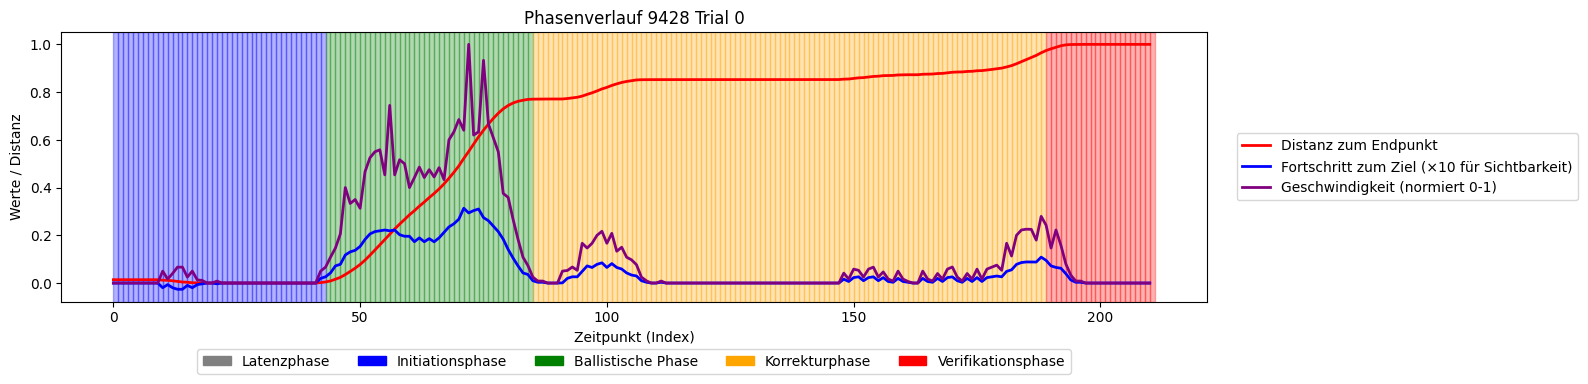

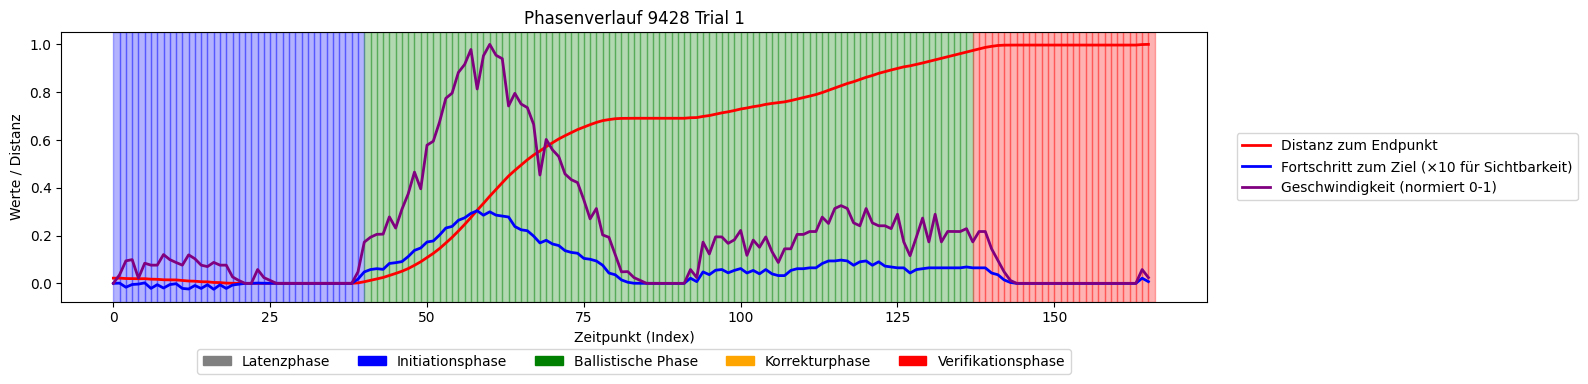

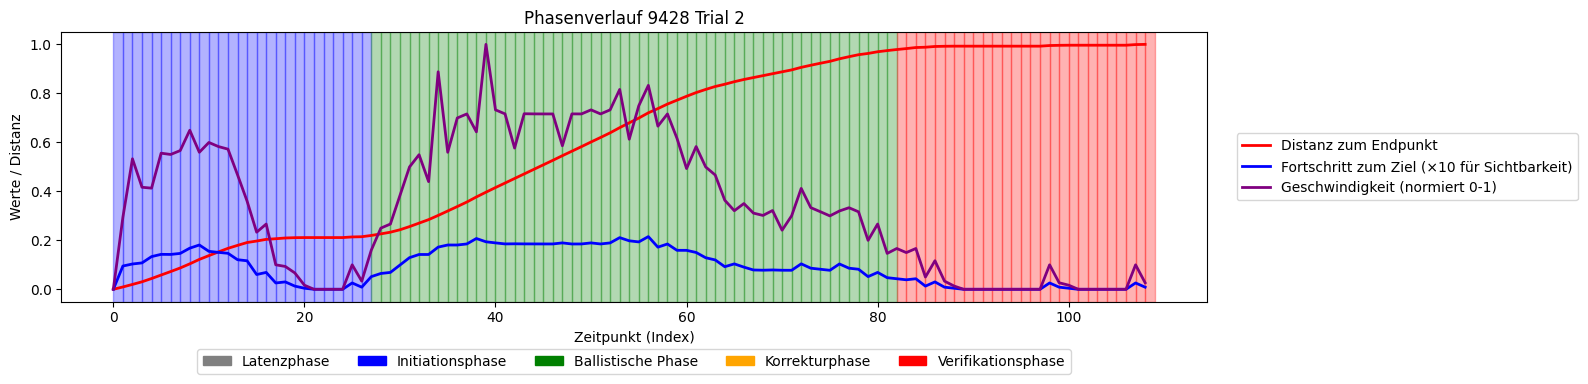

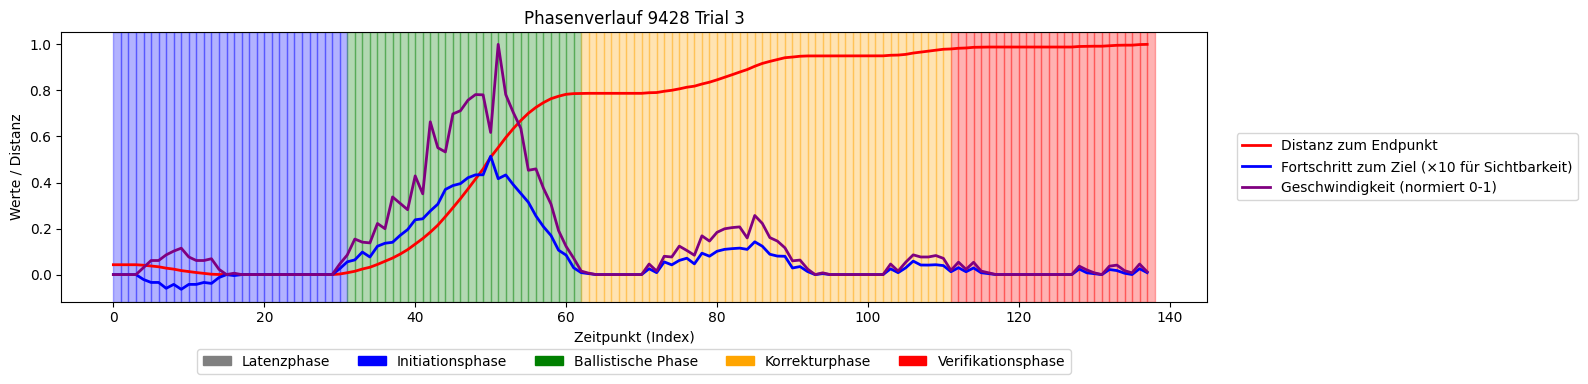

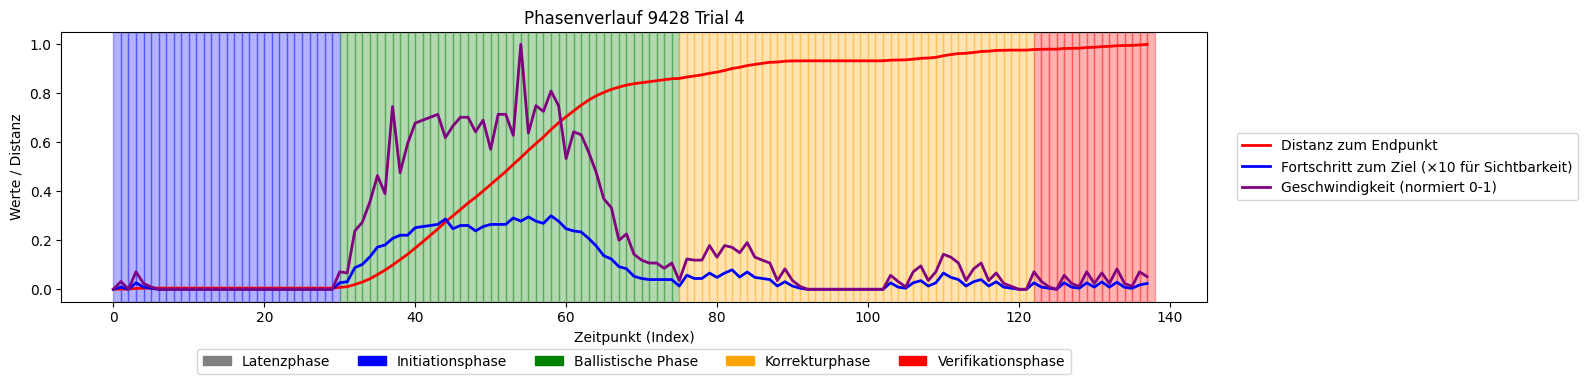

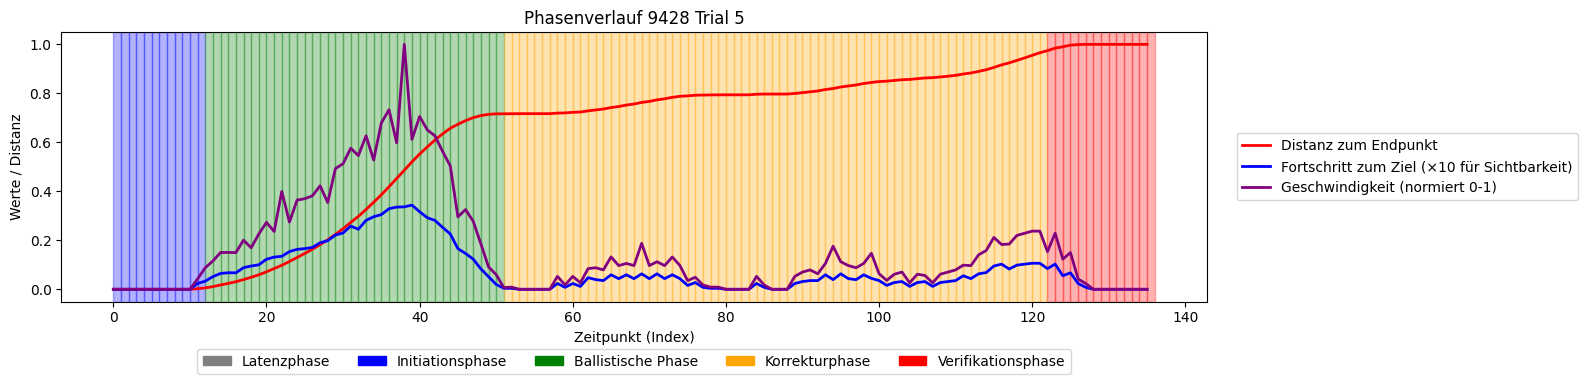

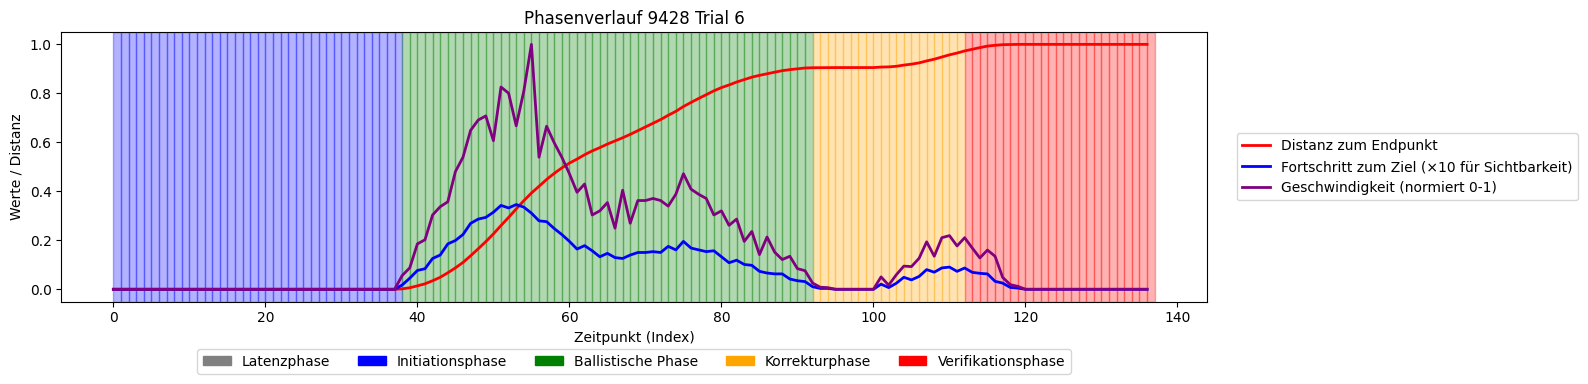

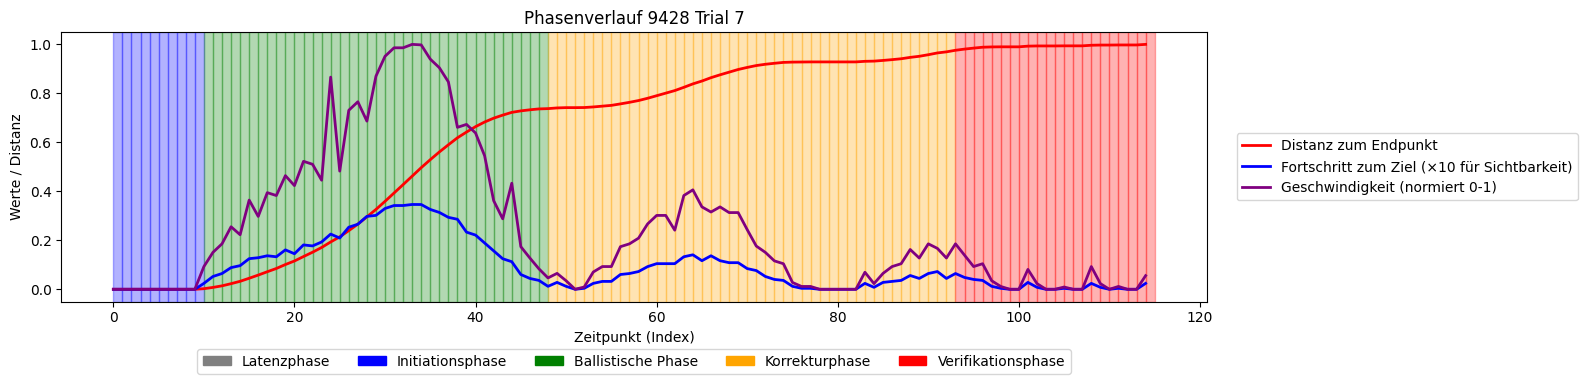

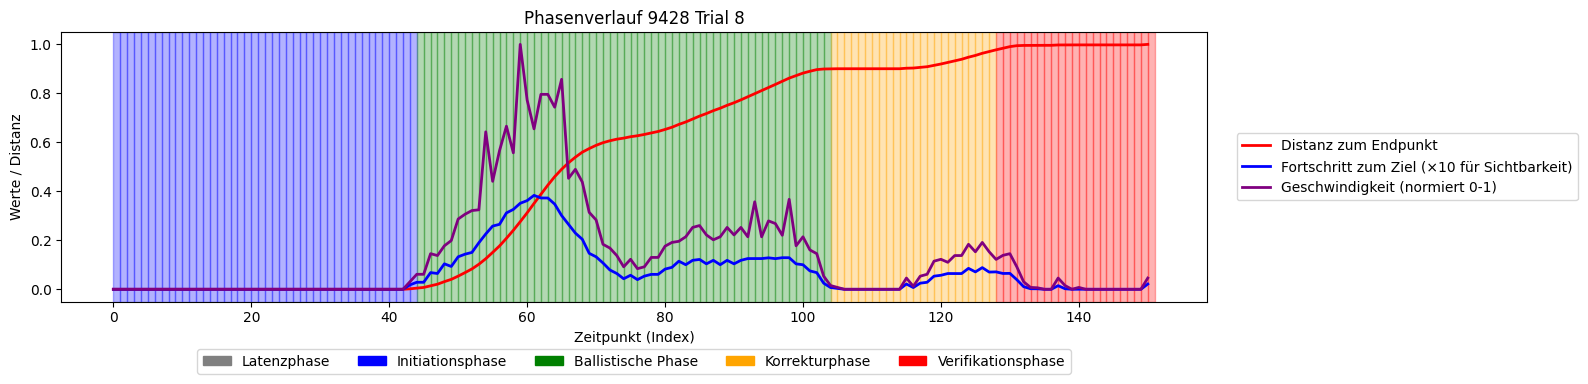

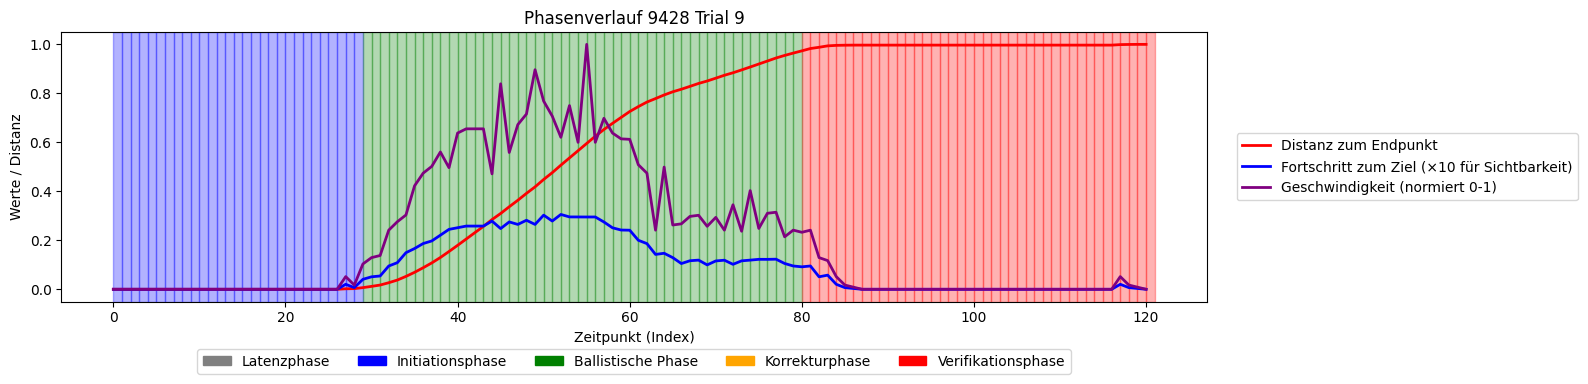

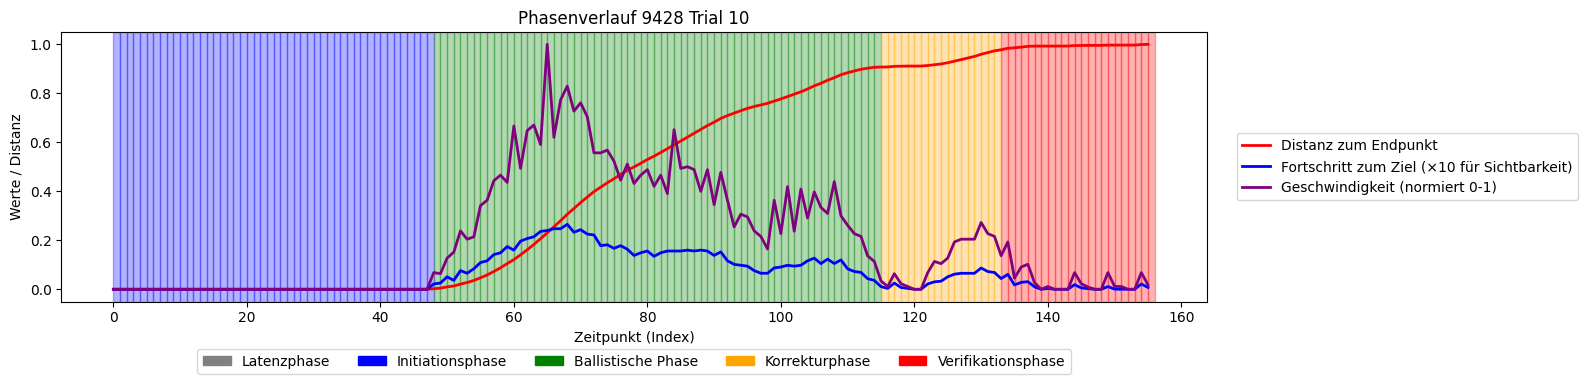

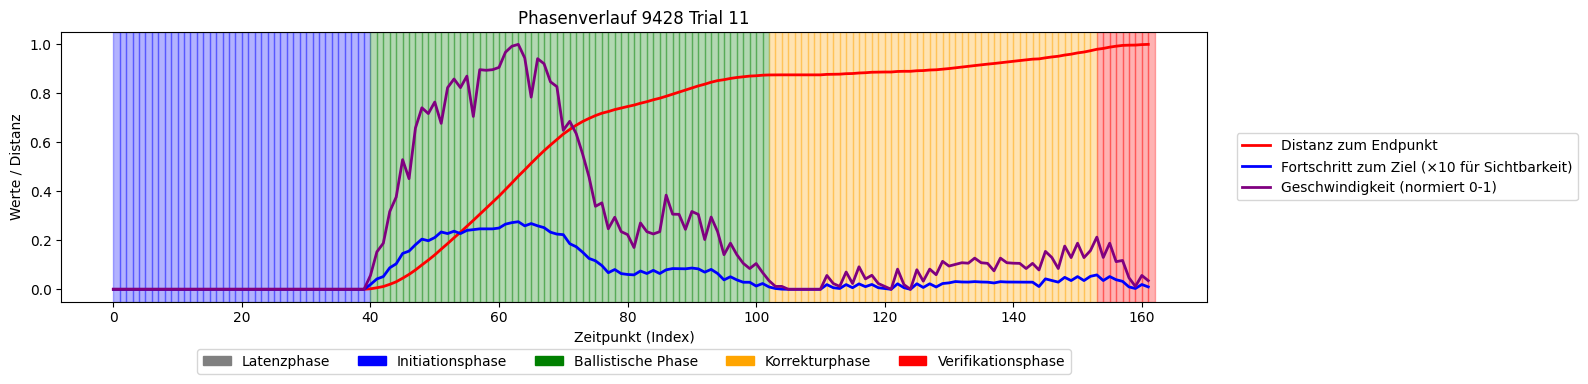

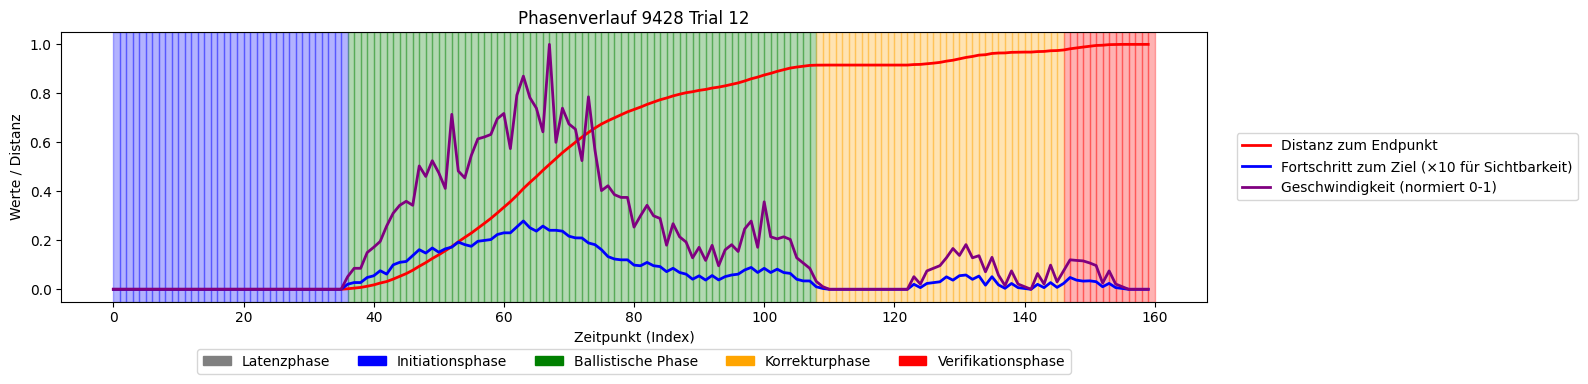

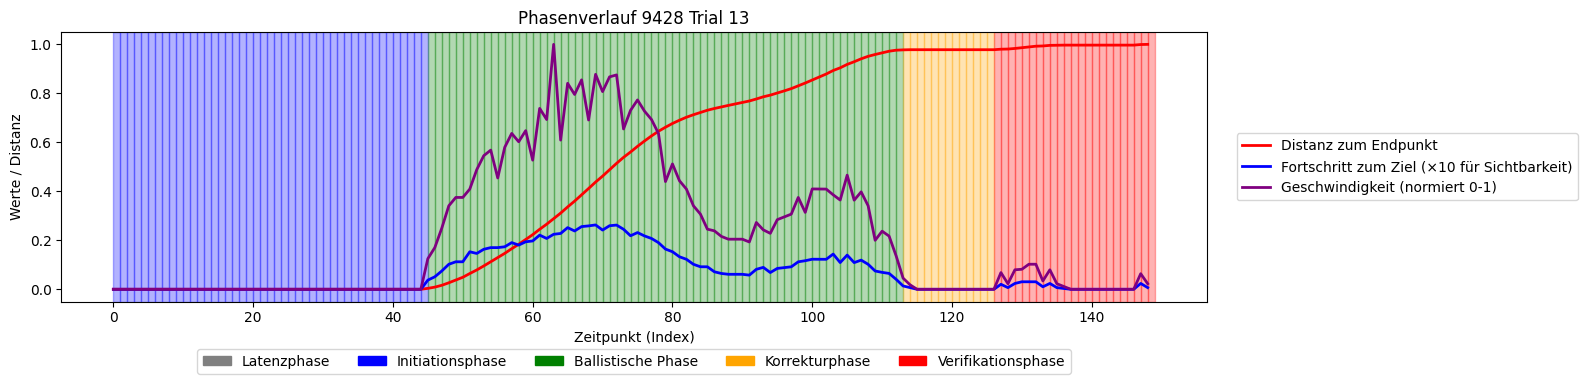

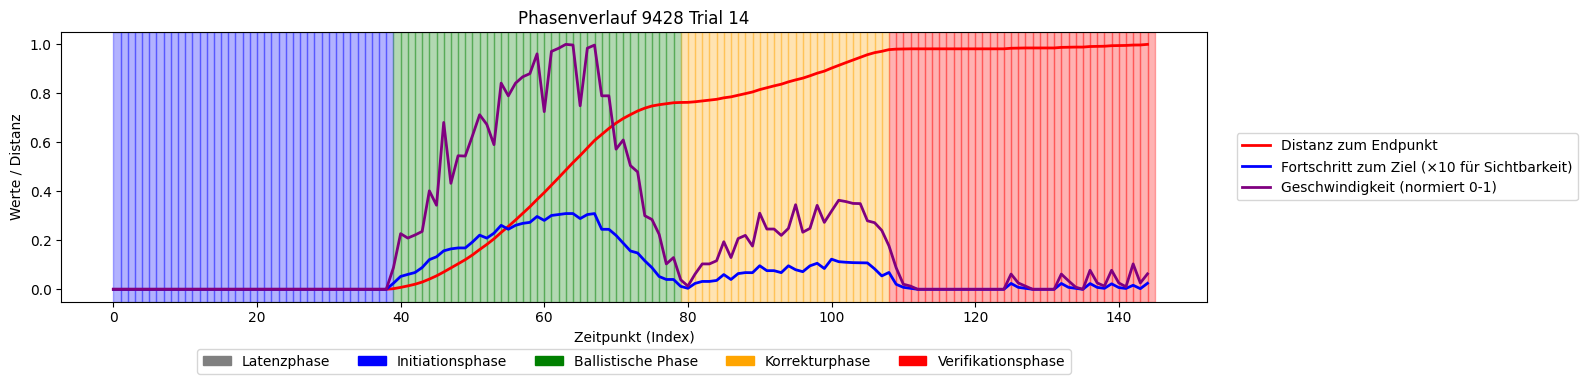

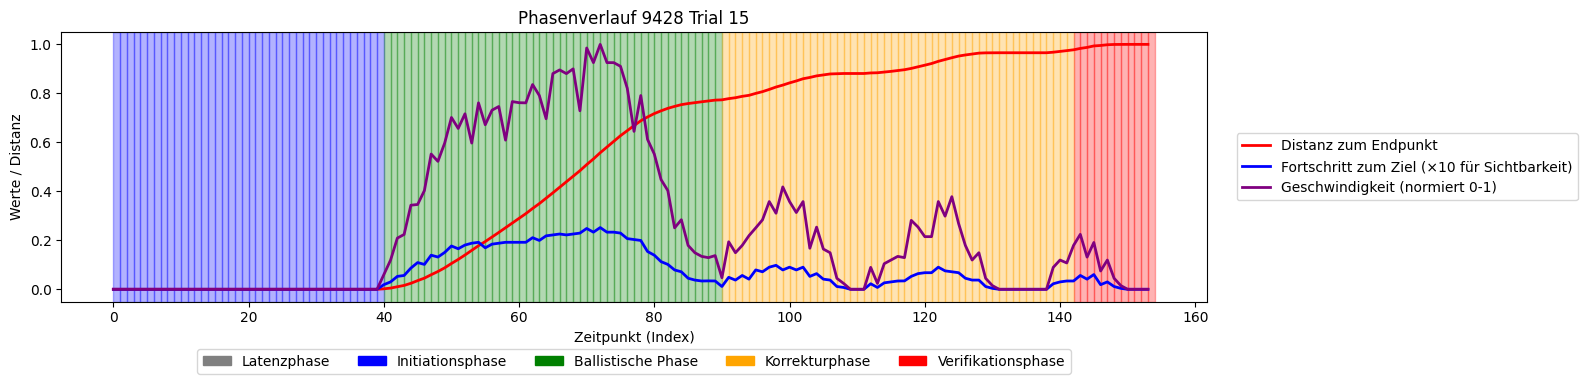

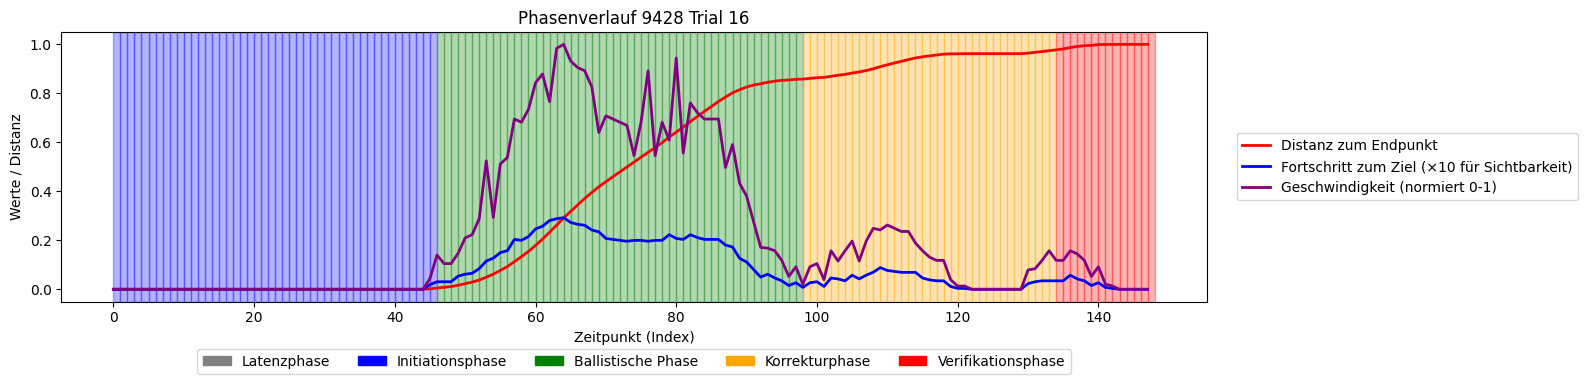

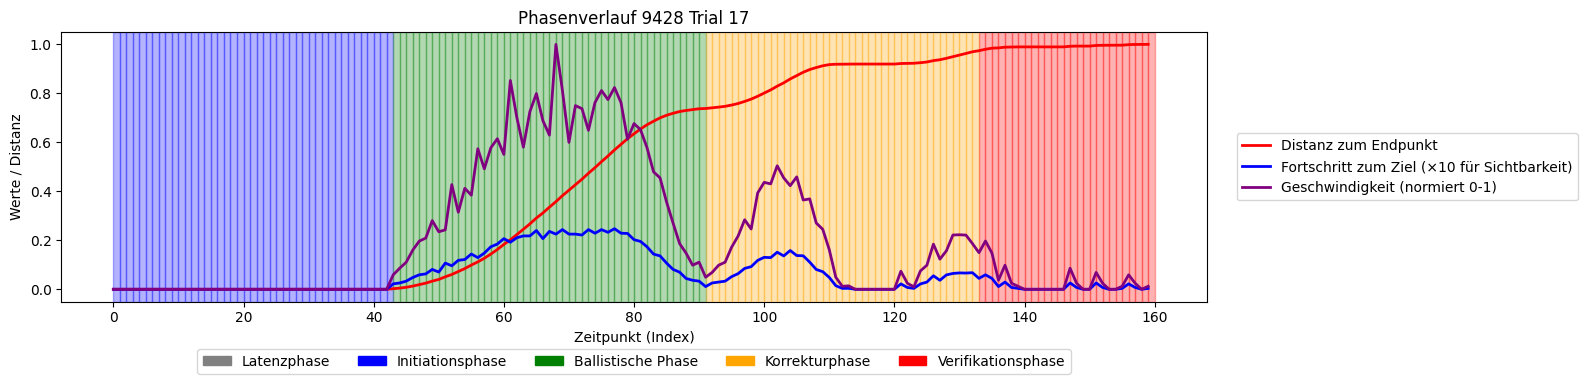

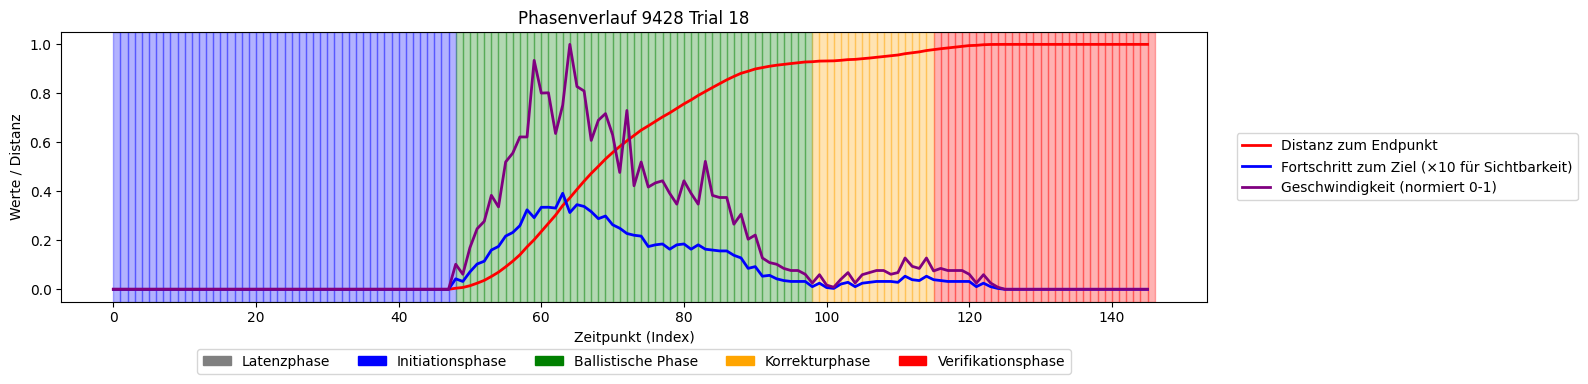

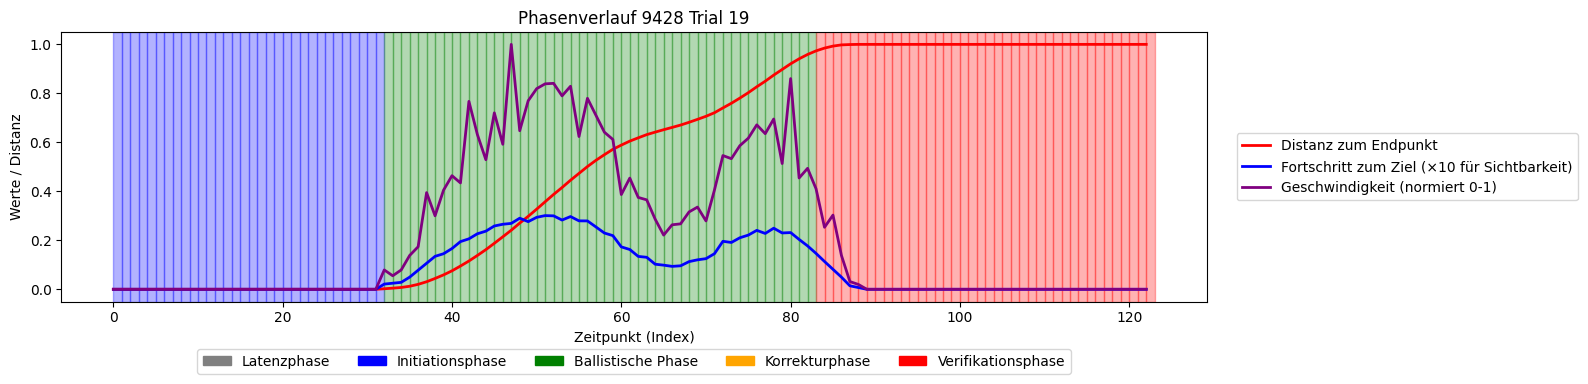

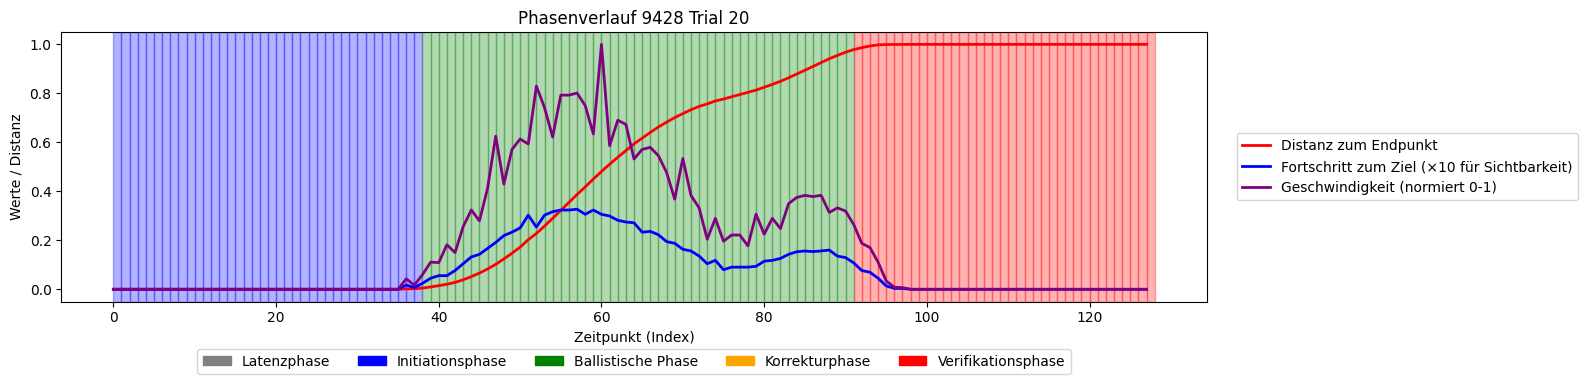

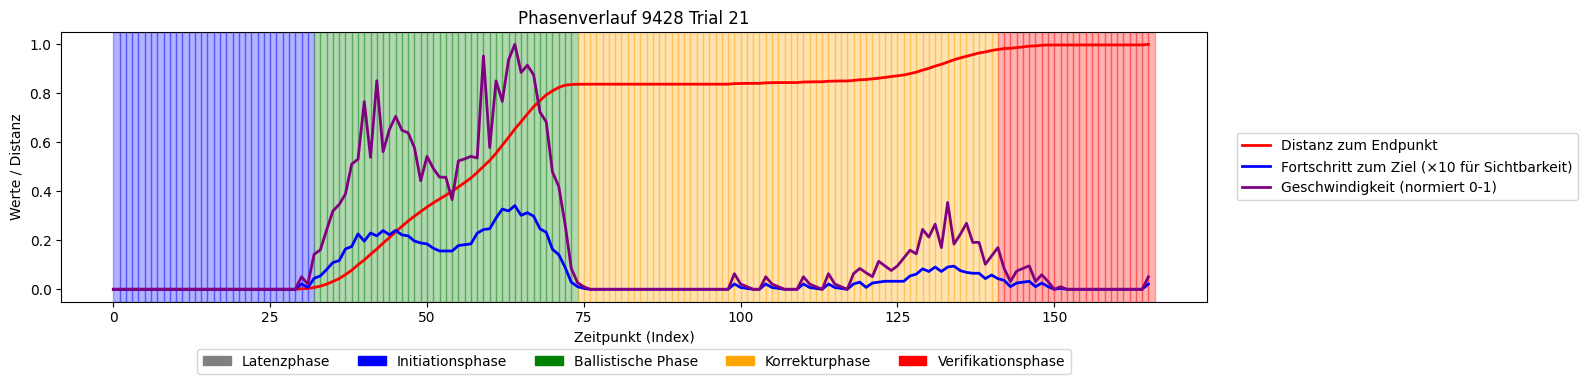

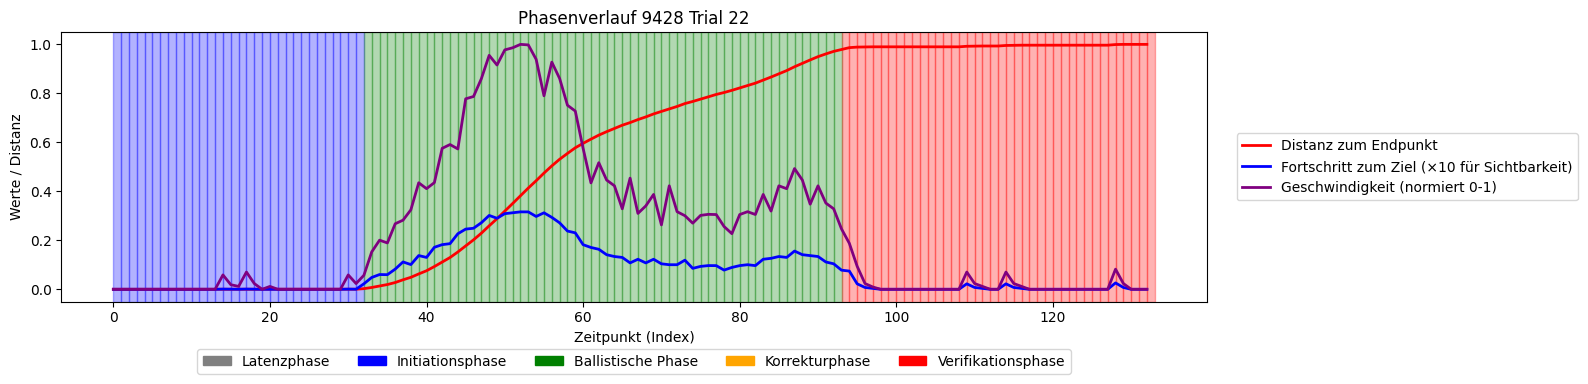

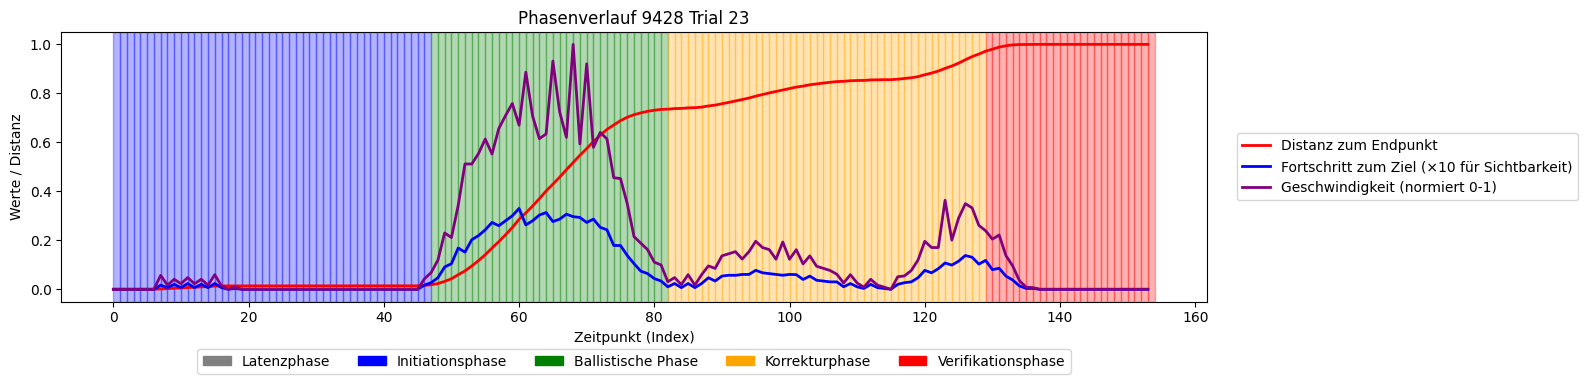

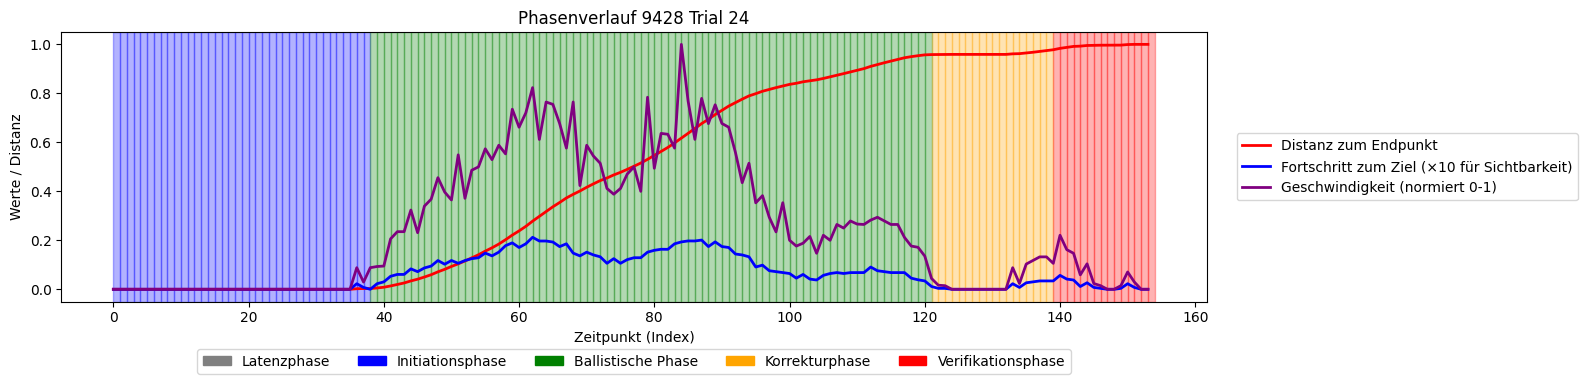

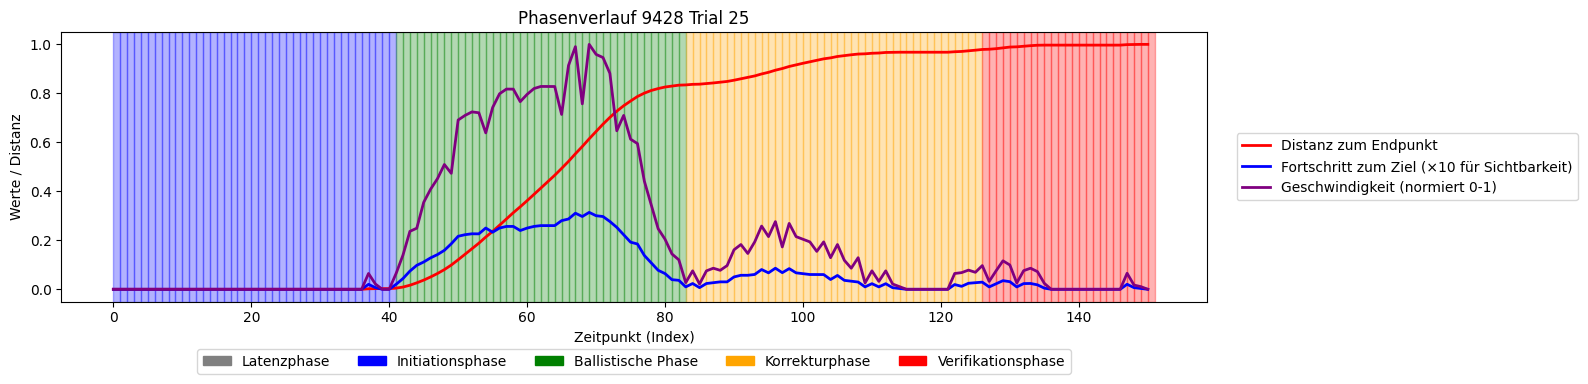

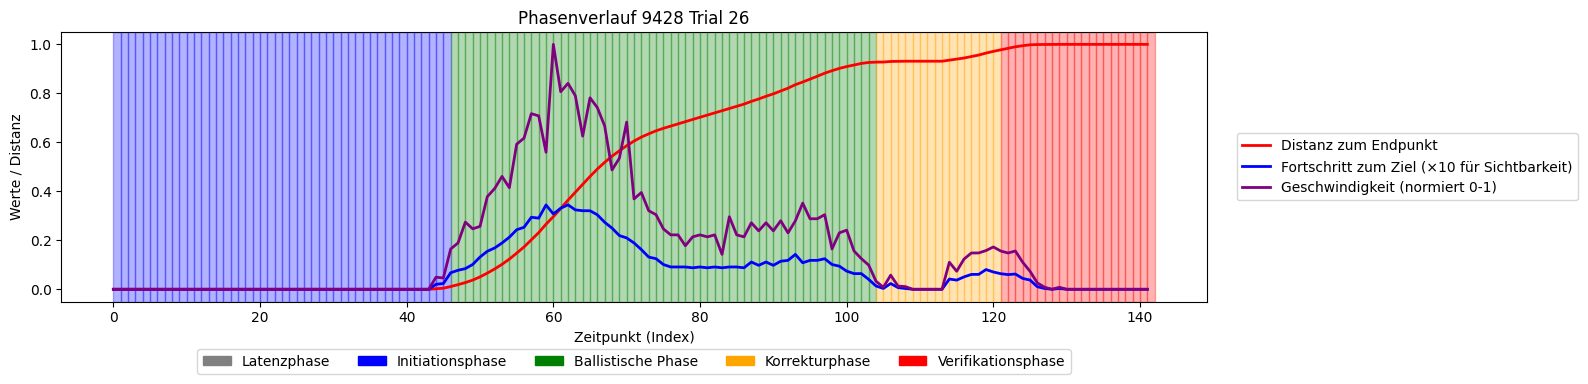

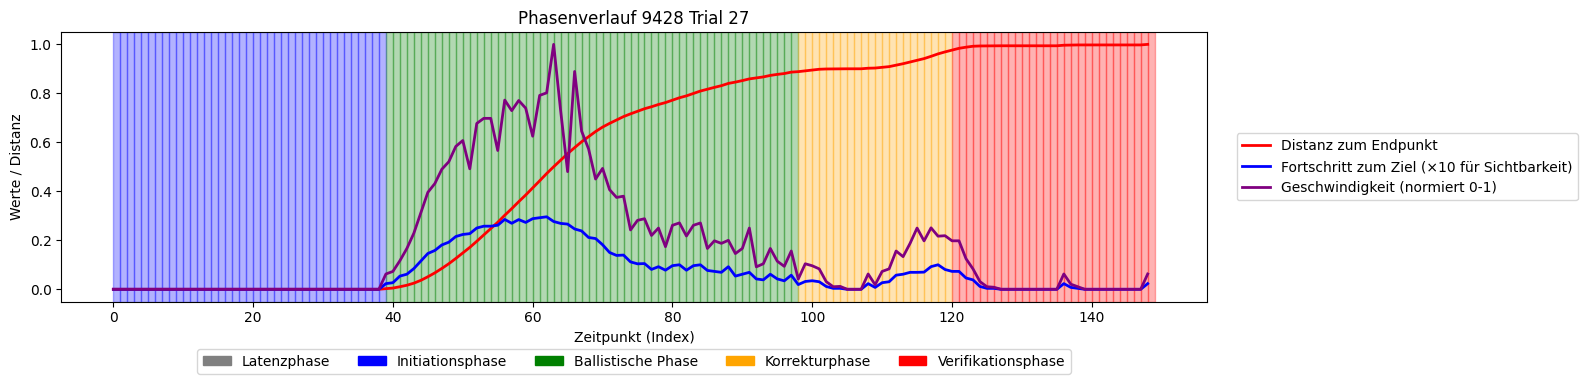

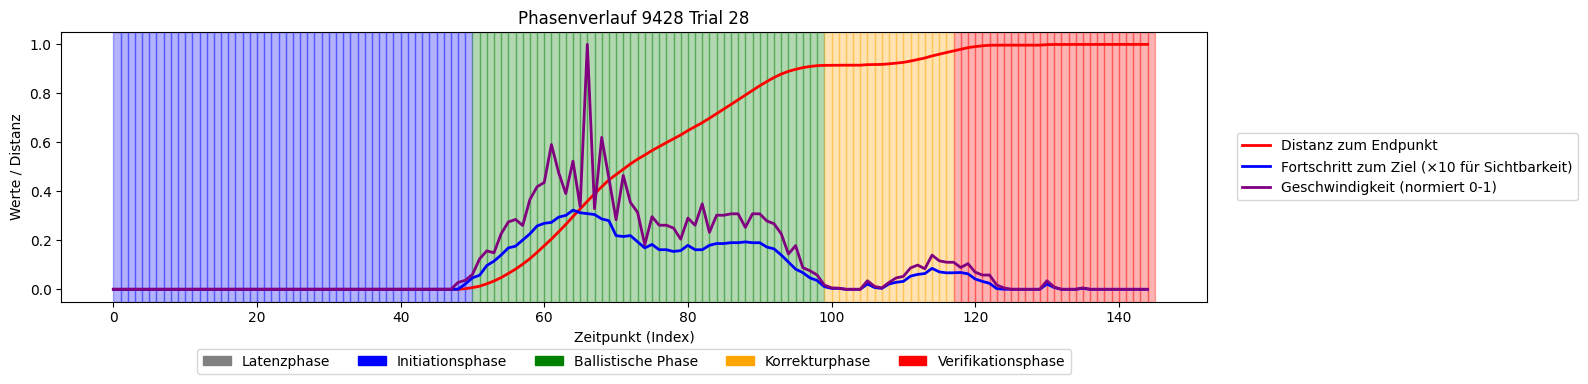

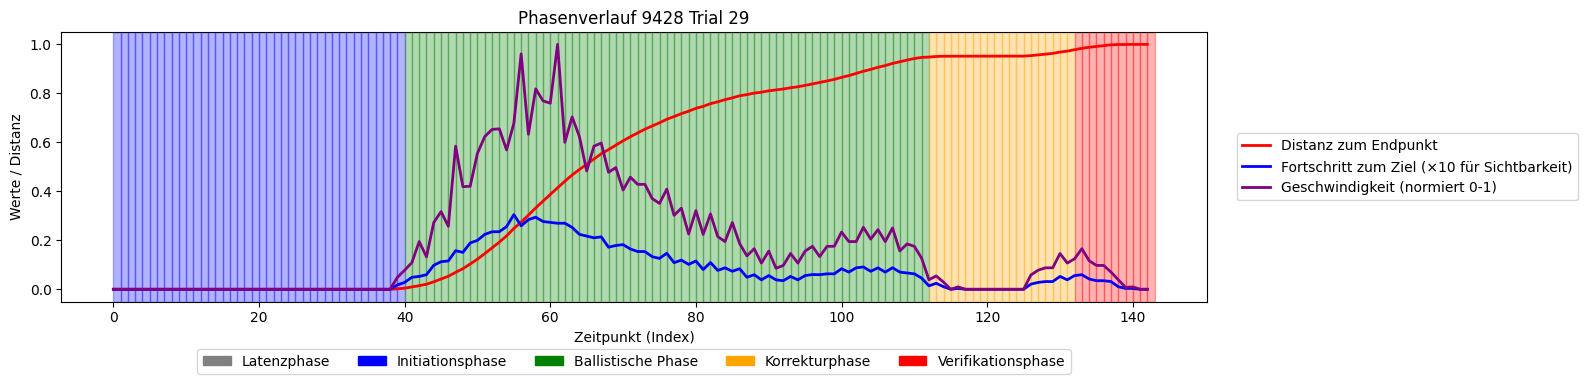

In [110]:
target_id = 9428
group_list = groups_dict["delay_7_8"]

try:
    idx = next(i for i, df in enumerate(group_list) if not df.empty and df.iloc[0]['id'] == target_id)
    
    for i in range(30):
        plot_phases(group_list[idx].iloc[i], index=1)
        
except StopIteration:
    print(f"ID {target_id} wurde in dieser Gruppe nicht gefunden.")

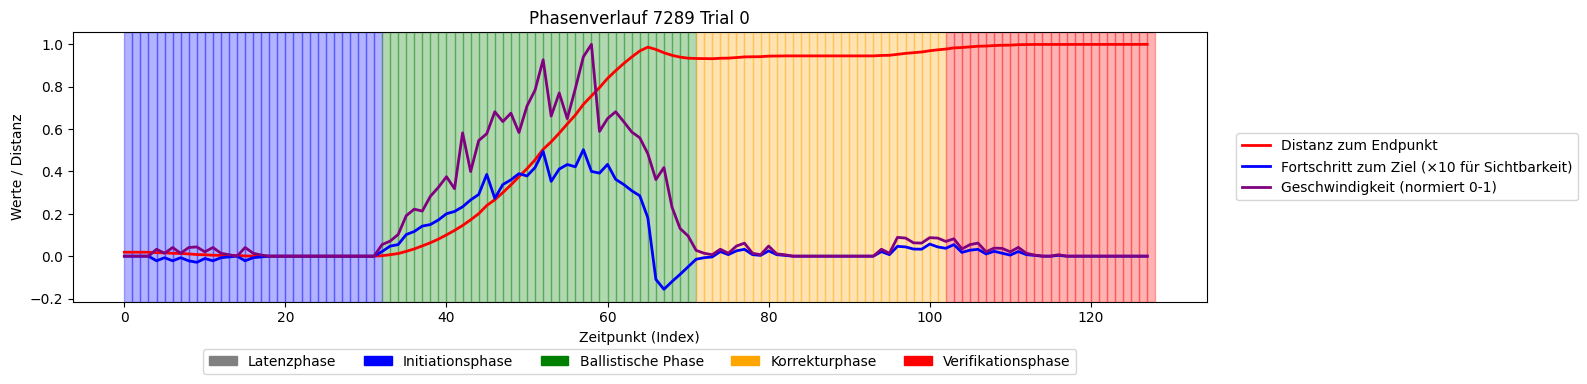

In [111]:
for i in range(1):
    plot_phases(groups_dict["delay_5_6"][30].iloc[i], index=1)

### Berechnung von Kennwerten der ballistischen Phase

Die Funktion `calc_ballistic_metrics` extrahiert aus einem Trial-Row folgende Kennwerte:

1. **time_to_ballistic_start** → Zeit in Millisekunden bis zum Beginn der ersten Ballistischen Phase  
2. **avg_ballistic_speed** → Durchschnittliche Geschwindigkeit während aller Zeitpunkte der Ballistischen Phase  
3. **max_ballistic_speed** → Maximale Geschwindigkeit während der Ballistischen Phase  
4. **verification_duration** → Dauer der Verifikationsphase in Millisekunden  

**Vorgehensweise:**
- Zuerst wird geprüft, ob überhaupt eine Ballistische Phase vorhanden ist.  
- Dann werden die Indizes dieser Phase(n) ermittelt.  
- Aus der Zeitreihe `elapsed_time_ms` wird die Zeit bis zum Start der Ballistik bestimmt.  
- Aus `speed_per_point` wird die durchschnittliche und maximale Geschwindigkeit während der Ballistik berechnet.  
- Schließlich wird die Dauer der Verifikationsphase aus den entsprechenden Zeitpunkten bestimmt.  

Wenn keine Ballistische Phase vorhanden ist, werden die Werte `None` zurückgegeben.


In [112]:
def calc_ballistic_metrics(row):
    phases = row['phases']
    elapsed = row['elapsed_time_ms']
    speed_per_point = row['speed_per_point']

    res = {
        'time_to_ballistic_start': None,
        'avg_ballistic_speed': None,
        'max_ballistic_speed': None,
        'verification_duration': 0.0,
        'correction_duration': 0.0,
        'ballistic_duration': 0.0
    }

    ballistic_indices = [i for i, p in enumerate(phases) if p == 'Ballistische Phase']
    if ballistic_indices:
        res['time_to_ballistic_start'] = elapsed[ballistic_indices[0]]
        res['ballistic_duration'] = elapsed[ballistic_indices[-1]] - elapsed[ballistic_indices[0]]
        
        speeds = [speed_per_point[i] for i in ballistic_indices]
        if speeds:
            res['avg_ballistic_speed'] = sum(speeds) / len(speeds)
            res['max_ballistic_speed'] = float(np.max(speeds))

    ver_indices = [i for i, p in enumerate(phases) if p == 'Verifikationsphase']
    if ver_indices:
        res['verification_duration'] = elapsed[ver_indices[-1]] - elapsed[ver_indices[0]]

    corr_indices = [i for i, p in enumerate(phases) if p == 'Korrekturphase']
    if corr_indices:
        res['correction_duration'] = elapsed[corr_indices[-1]] - elapsed[corr_indices[0]]

    return pd.Series(res)

### Zählen von Überschüssen (Overshoots) und Unterschüssen (Undershoots)

Die Funktion `count_overshoot_undershoot` analysiert die Korrekturphase eines Trials und ermittelt:

1. **overshoots** → Anzahl der Richtungswechsel von positiv zu negativ im Fortschritt, d.h. der Cursor bewegt sich über das Ziel hinaus und kehrt zurück.  
2. **undershoots** → Anzahl der Richtungswechsel von negativ zu positiv, d.h. der Cursor bewegt sich unterhalb des Ziels zurück Richtung Ziel.  

**Vorgehensweise:**
- Zuerst werden die Indizes der Korrekturphase in `phases` ermittelt.  
- Nur die `progress_to_target`-Werte dieser Phase werden betrachtet.  
- Die Vorzeichen der Schritte (`np.sign`) werden bestimmt, um Richtungswechsel zu erkennen.  
- Nullwerte werden so behandelt, dass sie die Richtung des letzten gültigen Schritts übernehmen.  
- Jeder Wechsel von +1 → -1 wird als Overshoot, jeder Wechsel von -1 → +1 als Undershoot gezählt.  

Wenn keine Korrekturphase oder zu wenige Punkte vorhanden sind, werden `overshoots` und `undershoots` als 0 zurückgegeben.


In [113]:
def count_overshoot_undershoot(row):
    progress = row['progress_to_target']
    phases = row['phases']

    if not progress or len(progress) < 2:
        return pd.Series({'overshoots': 0, 'undershoots': 0})
    
    correction_indices = [i for i, phase in enumerate(phases) if phase == 'Korrekturphase']
    if not correction_indices:
        return pd.Series({'overshoots': 0, 'undershoots': 0})

    progress = [progress[i] for i in correction_indices]

    if len(progress) < 2:
        return pd.Series({'overshoots': 0, 'undershoots': 0})

    overshoots = 0
    undershoots = 0

    signs = np.sign(progress)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i-1]

    for prev, curr in zip(signs[:-1], signs[1:]):
        if prev == 1 and curr == -1:
            overshoots += 1
        elif prev == -1 and curr == 1:
            undershoots += 1

    return pd.Series({'overshoots': overshoots, 'undershoots': undershoots})


In [114]:
import numpy as np

def calculate_auc(row):
    x = np.array(row['pointerX'])
    y = np.array(row['pointerY'])
    
    if len(x) < 2:
        return 0.0
    
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    
    points = np.vstack((x, y)).T - p1
    p2_rel = p2 - p1
    
    angle = -np.arctan2(p2_rel[1], p2_rel[0])
    c, s = np.cos(angle), np.sin(angle)
    R = np.array(((c, -s), (s, c)))
    
    points_rot = points @ R.T
    
    y_vals = np.abs(points_rot[:, 1])
    x_vals = points_rot[:, 0]
    area = np.trapezoid(y_vals, x=x_vals)

    
    return area

In [115]:
for group_name, df_list in groups_dict.items():
    for i, df in enumerate(df_list):
        try:
            metrics = df.apply(calc_ballistic_metrics, axis=1)
            df['time_to_ballistic_start'] = metrics['time_to_ballistic_start']
            df['avg_ballistic_speed'] = metrics['avg_ballistic_speed']
            df['max_ballistic_speed'] = metrics['max_ballistic_speed']
            df['verification_duration'] = metrics['verification_duration']
            df['correction_duration'] = metrics['correction_duration']
            df['ballistic_duration'] = metrics['ballistic_duration']
            counts = df.apply(count_overshoot_undershoot, axis=1)
            df['overshoots'] = counts['overshoots']
            df['undershoots'] = counts['undershoots']
            df['auc'] = df.apply(calculate_auc, axis=1)
        except Exception as e:
            print(f"Fehler bei {group_name}[{i}]: {e}")
            continue

In [116]:
def extract_pair_label(group_name):
    return group_name.split("_")[-2] + "_" + group_name.split("_")[-1]


### Zusammenführung der Kennwerte

Extrahiert aus allen Trials die relevanten Metriken (`time_to_ballistic_start`, `avg_ballistic_speed`, `overshoots`, `undershoots`, `max_ballistic_speed`, `verification_duration`), ergänzt um `pair` (Block-Paar) und `condition` (delay / no_delay) und erstellt daraus einen Gesamt-DataFrame `plot_df`.


In [117]:
all_rows = []

for group_name, df_list in groups_dict.items():
    for df in df_list:
        if "time_to_ballistic_start" not in df:
            continue

        temp_df = df[["id", "round", "trial","time_to_ballistic_start", "avg_ballistic_speed", "overshoots", "undershoots", "max_ballistic_speed", "verification_duration", "correction_duration", "ballistic_duration", "auc"]].copy()
        temp_df["pair"] = extract_pair_label(group_name) 
        temp_df["condition"] = "delay" if group_name.startswith("delay") else "no_delay"
        

        all_rows.append(temp_df)

plot_df = pd.concat(all_rows, ignore_index=True)


### Aggregation der Kennwerte pro Teilnehmer, Bedingung und Block-Paar

Berechnet den **Mittelwert** aller Kennwerte (`time_to_ballistic_start`, `avg_ballistic_speed`, `overshoots`, `undershoots`, `max_ballistic_speed`, `verification_duration`) für jede Kombination aus `id`, `condition` und `pair` und speichert das Ergebnis in `agg_df`.


In [118]:
agg_df = (
    plot_df
    .groupby(["id", "condition", "pair"], as_index=False)
    .agg({
        "time_to_ballistic_start": "mean",
        "avg_ballistic_speed": "mean",
        "overshoots": "mean",
        "undershoots": "mean",
        "max_ballistic_speed": "mean",
        "verification_duration": "mean",
        "correction_duration": "mean",
        "ballistic_duration": "mean",
        "auc": "mean"
    })
)


In [119]:
agg_df

,id,condition,pair,time_to_ballistic_start,avg_ballistic_speed,overshoots,undershoots,max_ballistic_speed,verification_duration,correction_duration,ballistic_duration,auc
0,1062,delay,1_2,220.250000,16.381319,0.057692,0.230769,33.610066,76.538462,65.211538,171.057692,0.110950
1,1062,delay,3_4,205.788462,16.443773,0.019231,0.211538,31.556219,94.807692,52.153846,177.192308,0.156803
2,1062,delay,5_6,207.173077,16.820034,0.115385,0.461538,34.019841,103.269231,87.923077,182.307692,0.113325
3,1062,delay,7_8,209.377778,18.597047,0.022222,0.133333,34.026858,58.288889,20.600000,151.111111,0.100952
4,1062,no_delay,1_2,216.148148,15.369429,0.055556,0.092593,30.763832,85.740741,42.148148,164.685185,0.092510
...,...,...,...,...,...,...,...,...,...,...,...,...
299,9993,delay,7_8,172.789474,14.559772,0.000000,0.017544,31.901002,105.228070,42.614035,198.982456,0.113686
300,9993,no_delay,1_2,170.881356,11.906800,0.016949,0.067797,26.788749,95.576271,72.406780,225.830508,0.153116
301,9993,no_delay,3_4,153.357143,15.257518,0.035714,0.178571,31.247951,107.982143,128.678571,176.946429,0.172245
302,9993,no_delay,5_6,150.321429,16.375823,0.035714,0.125000,34.866757,103.642857,88.196429,168.607143,0.106771


In [120]:
agg_df.to_csv("agg_df.csv", index=False, encoding="utf-8")